In [155]:
"""
02-TestMFCC.ipynb
=================
Notebook de prueba para verificar que el pipeline de extracción de MFCCs
es consistente con el usado en entrenamiento (03-3, 04-3, 05-2).

Parámetros consistentes:
- SR: 16kHz
- Trim: 30dB
- Segmentación: 2s con hop 1s
- MFCCs: 33 raw → eliminar C0 → 32 final
- Deltas: Δ + ΔΔ
- Shape final: (3, 32, T_frames)
"""

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# PARÁMETROS DE PREPROCESAMIENTO

# === Audio Configuration ===
SR = 16000              # Sample rate (resample todo a 16kHz)
TRIM_DB = 30            # Top dB para trim (eliminar silencios)

# === Segmentación ===
SEG_SEC = 2.0           # Duración de cada segmento: 2 segundos
HOP_SEC = 1.0           # Hop entre segmentos: 1 segundo (50% overlap)

# === MFCC Feature Extraction ===
# Ventana: 25ms, Hop: 10ms (estándar en ASR)
N_FFT = int(0.025 * SR)       # 25ms → 400 muestras
HOP_LEN = int(0.010 * SR)     # 10ms → 160 muestras

# Frecuencias
FMIN = 20                     # Frecuencia mínima (Hz)
FMAX = SR // 2                # Frecuencia máxima (Nyquist): 8000 Hz

# Coeficientes MFCC
N_MFCC_RAW = 33               # Extraemos 33 MFCCs inicialmente
N_MFCC_FINAL = 32             # Eliminamos C0 → 32 coeficientes finales
ADD_DELTAS = True             # Incluir Δ (delta) y ΔΔ (delta-delta)

print("="*70)
print("CONFIGURACIÓN DE PREPROCESAMIENTO - CONSISTENTE CON PRODUCCIÓN")
print("="*70)
print(f"Sample Rate:        {SR} Hz")
print(f"Trim dB:            {TRIM_DB} dB")
print(f"Segment Duration:   {SEG_SEC} s")
print(f"Segment Hop:        {HOP_SEC} s")
print(f"Win Length (n_fft): {N_FFT} samples ({N_FFT/SR*1000:.1f} ms)")
print(f"Hop Length:         {HOP_LEN} samples ({HOP_LEN/SR*1000:.1f} ms)")
print(f"Freq Range:         {FMIN}-{FMAX} Hz")
print(f"MFCCs (raw):        {N_MFCC_RAW} (includes C0)")
print(f"MFCCs (final):      {N_MFCC_FINAL} (C0 removed)")
print(f"Deltas:             {ADD_DELTAS} (Δ + ΔΔ)")
if ADD_DELTAS:
    print(f"Final Shape/Seg:    (3, {N_MFCC_FINAL}, T_frames) → [MFCC, Δ, ΔΔ]")
else:
    print(f"Final Shape/Seg:    (1, {N_MFCC_FINAL}, T_frames)")
print("="*70)

CONFIGURACIÓN DE PREPROCESAMIENTO - CONSISTENTE CON PRODUCCIÓN
Sample Rate:        16000 Hz
Trim dB:            30 dB
Segment Duration:   2.0 s
Segment Hop:        1.0 s
Win Length (n_fft): 400 samples (25.0 ms)
Hop Length:         160 samples (10.0 ms)
Freq Range:         20-8000 Hz
MFCCs (raw):        33 (includes C0)
MFCCs (final):      32 (C0 removed)
Deltas:             True (Δ + ΔΔ)
Final Shape/Seg:    (3, 32, T_frames) → [MFCC, Δ, ΔΔ]


In [157]:
def peak_normalize(x, eps=1e-9):
    """
    Normalización por pico (peak normalization).
    Se aplica DESPUÉS de trim y ANTES de segmentar (a nivel de archivo completo).
    
    Args:
        x: señal de audio (1D numpy array)
        eps: epsilon para evitar división por cero
    
    Returns:
        Audio normalizado con pico = 1.0
    """
    return x / (np.max(np.abs(x)) + eps)


def segment_signal(x, sr, seg_sec, hop_sec):
    """
    Segmenta la señal de audio en ventanas con overlap.
    Si un segmento es más corto que seg_sec, se hace padding con reflect.
    
    Args:
        x: señal de audio (1D numpy array)
        sr: sample rate
        seg_sec: duración del segmento en segundos
        hop_sec: hop entre segmentos en segundos
    
    Returns:
        Lista de segmentos de audio
    """
    seg_len = int(seg_sec * sr)
    hop_len = int(hop_sec * sr)
    
    # Si el audio es más corto que seg_len, hacer padding
    if len(x) < seg_len:
        x = np.pad(x, (0, seg_len - len(x)), mode='reflect')
    
    segments = []
    for start in range(0, max(1, len(x) - seg_len + 1), hop_len):
        seg = x[start:start + seg_len]
        if len(seg) < seg_len:
            seg = np.pad(seg, (0, seg_len - len(seg)), mode='reflect')
        segments.append(seg)
    
    return segments


def extract_mfcc_features(audio_segment):
    """
    Extrae MFCCs siguiendo el pipeline de producción:
    1. Extrae N_MFCC_RAW (33) MFCCs
    2. Elimina C0 (primer coeficiente) → queda (32, T)
    3. Calcula Δ y ΔΔ sobre los 32 coeficientes
    4. Apila → (3, 32, T) si ADD_DELTAS=True
    
    IMPORTANTE: Esta función sigue EXACTAMENTE el mismo proceso que
    mfcc_features() en 03-3-Create_NPY(1275).ipynb
    
    Args:
        audio_segment: señal de audio (1D numpy array)
    
    Returns:
        features: numpy array con shape (channels, N_MFCC_FINAL, T_frames)
                  channels = 3 si ADD_DELTAS=True, else 1
    """
    # Extraer MFCCs con C0 incluido
    mfcc = librosa.feature.mfcc(
        y=audio_segment,
        sr=SR,
        n_mfcc=N_MFCC_RAW,      # 33 coeficientes
        n_fft=N_FFT,
        hop_length=HOP_LEN,
        fmin=FMIN,
        fmax=FMAX
    )
    
    # Eliminar C0 (primer coeficiente) → shape: (32, T)
    mfcc = mfcc[1:, :]
    
    if ADD_DELTAS:
        # Calcular deltas sobre los 32 coeficientes (sin C0)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        
        # Apilar: (3, 32, T)
        features = np.stack([mfcc, delta, delta2], axis=0)
    else:
        # Solo MFCCs: (1, 32, T)
        features = mfcc[np.newaxis, :, :]
    
    return features.astype(np.float32)

In [158]:
def preprocess_audio_file(audio_path, verbose=True):
    """
    Pipeline completo de preprocesamiento consistente con producción:
    
    CONTRATO DE PREPROCESAMIENTO (igual a 03-3-Create_NPY):
    1. Load + resample a 16kHz
    2. Trim (eliminar silencios con TRIM_DB=30)
    3. Peak normalization (sobre archivo completo DESPUÉS de trim)
    4. Segmentar en ventanas de 2s con hop de 1s
    5. Extraer MFCCs por segmento (33 → eliminar C0 → 32)
    6. Calcular deltas y delta-delta
    
    Args:
        audio_path: ruta al archivo de audio
        verbose: imprimir información de procesamiento
    
    Returns:
        segments_features: lista de arrays con shape (3, 32, T_frames)
        metadata: diccionario con información del procesamiento
    """
    audio_path = Path(audio_path)
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Procesando: {audio_path.name}")
        print(f"{'='*70}")
    
    # 1. Load + resample
    audio_raw, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    if verbose:
        print(f"1. Audio cargado: {len(audio_raw)} samples ({len(audio_raw)/SR:.2f}s)")
        print(f"   Peak antes de trim: {np.max(np.abs(audio_raw)):.4f}")
    
    # 2. Trim
    audio_trimmed, _ = librosa.effects.trim(audio_raw, top_db=TRIM_DB)
    if verbose:
        print(f"2. Después de trim: {len(audio_trimmed)} samples ({len(audio_trimmed)/SR:.2f}s)")
        print(f"   Peak después de trim: {np.max(np.abs(audio_trimmed)):.4f}")
    
    # 3. Peak normalization (a nivel de archivo)
    audio_normalized = peak_normalize(audio_trimmed)
    if verbose:
        print(f"3. Después de peak norm: peak={np.max(np.abs(audio_normalized)):.4f}")
    
    # 4. Segmentar
    segments = segment_signal(audio_normalized, SR, SEG_SEC, HOP_SEC)
    if verbose:
        print(f"4. Segmentos generados: {len(segments)}")
    
    # 5. Extraer features por segmento
    segments_features = []
    for i, seg in enumerate(segments):
        feat = extract_mfcc_features(seg)
        segments_features.append(feat)
        if verbose and i == 0:
            print(f"5. Shape del primer segmento: {feat.shape}")
    
    # Metadata
    metadata = {
        'filename': audio_path.name,
        'duration_original': len(audio_raw) / SR,
        'duration_trimmed': len(audio_trimmed) / SR,
        'num_segments': len(segments),
        'feature_shape': segments_features[0].shape if segments_features else None
    }
    
    if verbose:
        print(f"{'='*70}")
        print("Preprocesamiento completado")
        print(f"{'='*70}\n")
    
    return segments_features, metadata

In [ ]:
# ========================================================================
# EJEMPLO: Procesar un archivo de audio
# ========================================================================

# Si no tienes un archivo específico, puedes usar esta línea para buscar uno:
# AUDIO_PATH = list(Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files").rglob("*.wav"))[0]

AUDIO_PATH = r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files\2022-06-14--11-55-10_1__segment0.wav"

# Procesar el archivo
try:
    features, metadata = preprocess_audio_file(AUDIO_PATH, verbose=True)
    
    print("\n RESUMEN DEL PROCESAMIENTO:")
    print(f"   Archivo:            {metadata['filename']}")
    print(f"   Duración original:  {metadata['duration_original']:.2f}s")
    print(f"   Duración trimmed:   {metadata['duration_trimmed']:.2f}s")
    print(f"   Segmentos:          {metadata['num_segments']}")
    print(f"   Shape por segmento: {metadata['feature_shape']}")
    print(f"\n Features extraídas exitosamente!")
    
except FileNotFoundError:
    print("ERROR: Archivo no encontrado.")
    print("Por favor ajusta la variable AUDIO_PATH con la ruta correcta.")
except Exception as e:
    print(f"ERROR durante el procesamiento: {e}")


Procesando: 2022-06-14--11-55-10_1__segment0.wav
1. Audio cargado: 960000 samples (60.00s)
   Peak antes de trim: 1.0800
2. Después de trim: 960000 samples (60.00s)
   Peak después de trim: 1.0800
3. Después de peak norm: peak=1.0000
4. Segmentos generados: 59
5. Shape del primer segmento: (3, 32, 201)
Preprocesamiento completado


 RESUMEN DEL PROCESAMIENTO:
   Archivo:            2022-06-14--11-55-10_1__segment0.wav
   Duración original:  60.00s
   Duración trimmed:   60.00s
   Segmentos:          59
   Shape por segmento: (3, 32, 201)

 Features extraídas exitosamente!


In [160]:
import soundfile
soundfile.info(AUDIO_PATH)

C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files\2022-06-14--11-55-10_1__segment0.wav
samplerate: 22050 Hz
channels: 1
duration: 01:0.000 min
format: WAV (Microsoft) [WAV]
subtype: 32 bit float [FLOAT]

In [161]:
# ========================================================================
# TEST BATCH: Procesar múltiples archivos
# ========================================================================

# Directorio con audios
DATA_DIR = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files")

# Buscar los primeros 5 archivos WAV
audio_files = list(DATA_DIR.rglob("*.wav"))[:5]

if len(audio_files) == 0:
    print("No se encontraron archivos .wav en el directorio.")
else:
    print(f"\n{'='*70}")
    print(f"TEST BATCH: Procesando {len(audio_files)} archivos")
    print(f"{'='*70}\n")
    
    results = []
    for audio_path in audio_files:
        try:
            features, metadata = preprocess_audio_file(audio_path, verbose=False)
            results.append({
                'filename': metadata['filename'],
                'num_segments': metadata['num_segments'],
                'shape': metadata['feature_shape']
            })
            print(f"{metadata['filename']:<30} → {metadata['num_segments']:>3} segmentos")
        except Exception as e:
            print(f"{audio_path.name:<30} → ERROR: {e}")
    
    print(f"\n{'='*70}")
    print(f"Procesamiento batch completado: {len(results)}/{len(audio_files)} exitosos")
    print(f"{'='*70}")


TEST BATCH: Procesando 5 archivos

2022-06-05--17-41-01_2__segment0.wav →  58 segmentos
2022-06-05--17-41-01_2__segment1.wav →  59 segmentos
2022-06-05--17-41-01_2__segment2.wav →  59 segmentos
2022-06-05--17-41-01_2__segment3.wav →  59 segmentos
2022-06-05--17-41-01_2__segment4.wav →  59 segmentos

Procesamiento batch completado: 5/5 exitosos


In [162]:
# ========================================================================
# VALIDACIÓN: Comparar features con las del entrenamiento
# ========================================================================

# Cargar un segmento del dataset de entrenamiento
NPY_DIR = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled")

try:
    X_train = np.load(NPY_DIR / "X_train.npy", mmap_mode="r")
    
    print(f"\n{'='*70}")
    print("VALIDACIÓN DE CONSISTENCIA")
    print(f"{'='*70}")
    print(f"Shape del dataset de entrenamiento: {X_train.shape}")
    print(f"   Esperado: (N_samples, 3, 32, T_frames)")
    print(f"\nShape de nuestro test:")
    if 'features' in locals() and len(features) > 0:
        print(f"   {features[0].shape}")
        print(f"\n ¡Las dimensiones coinciden!" if features[0].shape[0] == 3 and features[0].shape[1] == 32 else "Las dimensiones NO coinciden")
    
    # Estadísticas comparativas
    print(f"\n Estadísticas de X_train (primer segmento):")
    sample = X_train[0].astype(np.float32)
    print(f"   Min:  {np.min(sample):.4f}")
    print(f"   Max:  {np.max(sample):.4f}")
    print(f"   Mean: {np.mean(sample):.4f}")
    print(f"   Std:  {np.std(sample):.4f}")
    
    if 'features' in locals() and len(features) > 0:
        print(f"\n Estadísticas de nuestro test (primer segmento):")
        print(f"   Min:  {np.min(features[0]):.4f}")
        print(f"   Max:  {np.max(features[0]):.4f}")
        print(f"   Mean: {np.mean(features[0]):.4f}")
        print(f"   Std:  {np.std(features[0]):.4f}")
    
    print(f"{'='*70}\n")
    
except FileNotFoundError:
    print("No se encontraron los archivos .npy de entrenamiento.")


VALIDACIÓN DE CONSISTENCIA
Shape del dataset de entrenamiento: (52551, 3, 32, 201)
   Esperado: (N_samples, 3, 32, T_frames)

Shape de nuestro test:
   (3, 32, 201)

 ¡Las dimensiones coinciden!

 Estadísticas de X_train (primer segmento):
   Min:  -246.3750
   Max:  146.6250
   Mean: 0.1108
   Std:  25.8674

 Estadísticas de nuestro test (primer segmento):
   Min:  -32.8825
   Max:  171.3966
   Mean: 1.4945
   Std:  16.5704



VISUALIZACIÓN DE FEATURES FINALES (usadas en el modelo)


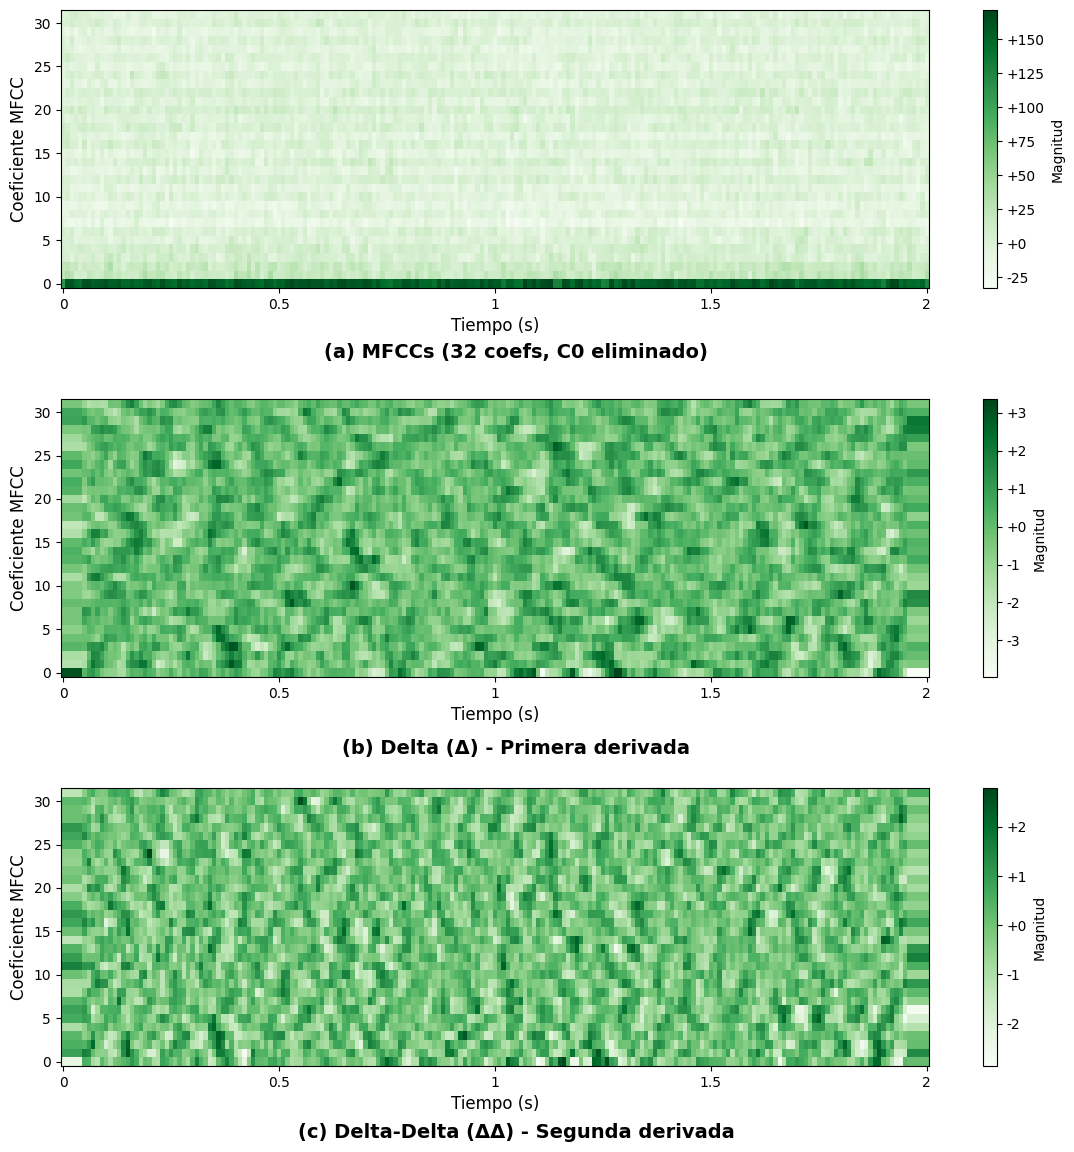

\n✓ Visualización de features finales completada
  Shape: (3, 32, 201) → (canales, coeficientes, frames)
\n======================================================================
VISUALIZACIÓN DE C0 (coeficiente eliminado)
NOTA: C0 representa la energía promedio del espectro y suele eliminarse
      porque no aporta información discriminativa para clasificación.\n


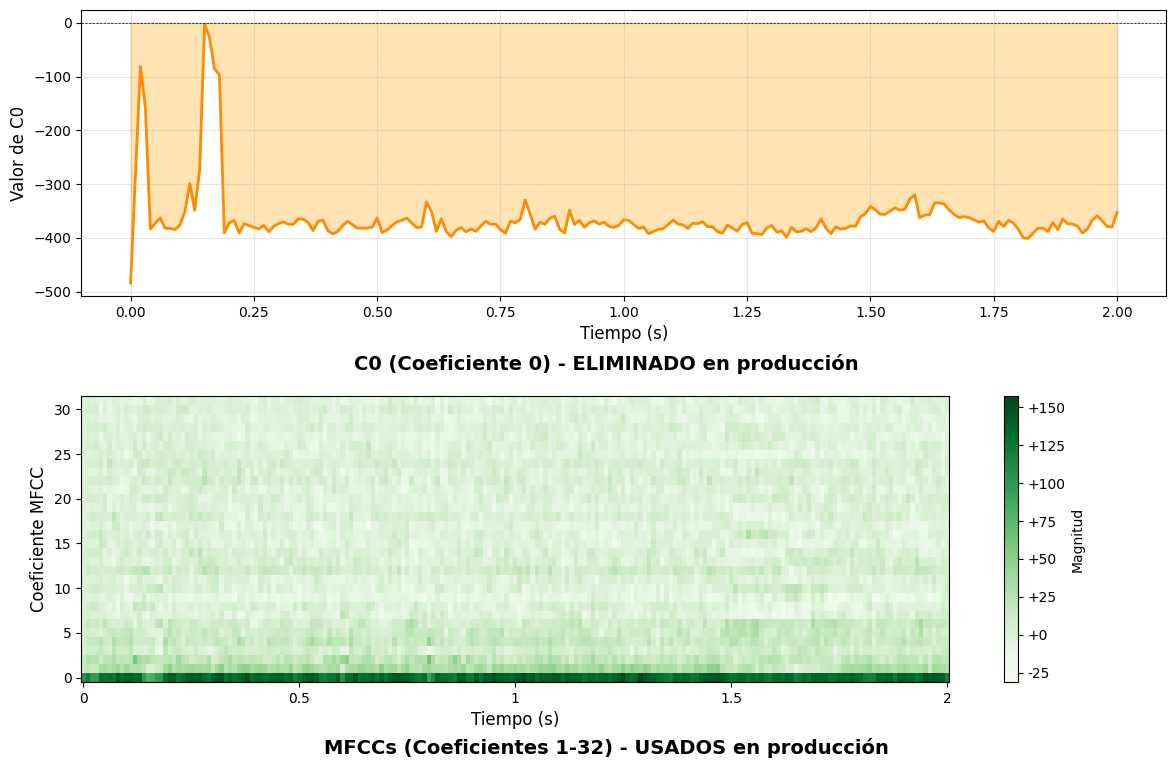

\n✓ Visualización de C0 completada
  Shape con C0:    (33, 201) → (33, frames)
  Shape sin C0:    (32, 201) → (32, frames)
  C0 promedio:     -364.05
  C0 rango:        [-483.97, -2.79]
  C0 std:          55.03
\n======================================================================
VISUALIZACIÓN COMPLETA: C0 + MFCCs 1-32


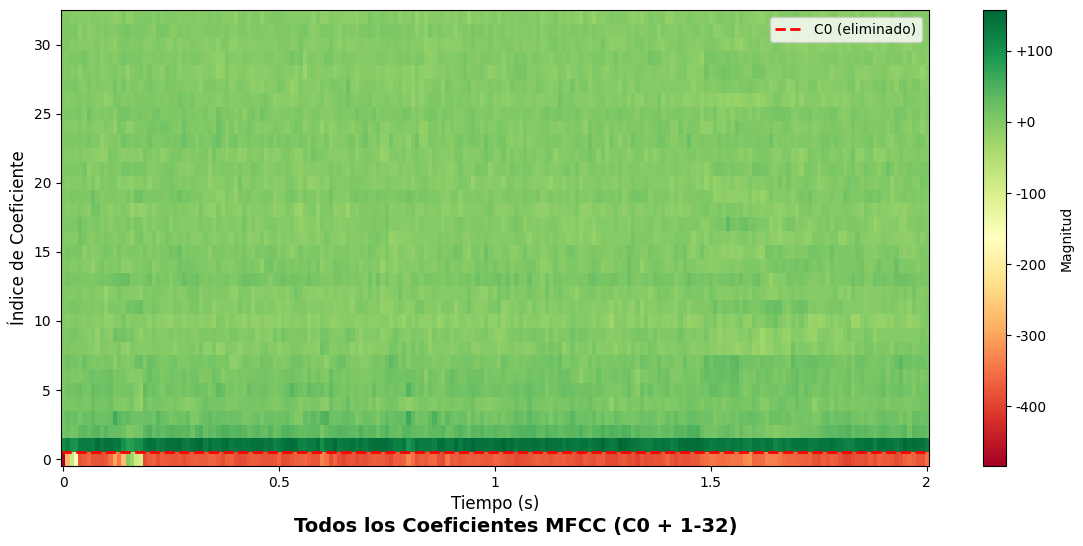

\n✓ Visualización completa generada
  Observa cómo C0 (fila 0) tiene un comportamiento diferente al resto
\n======================================================================
COMPARACIÓN DE ESCALAS DE COLORES


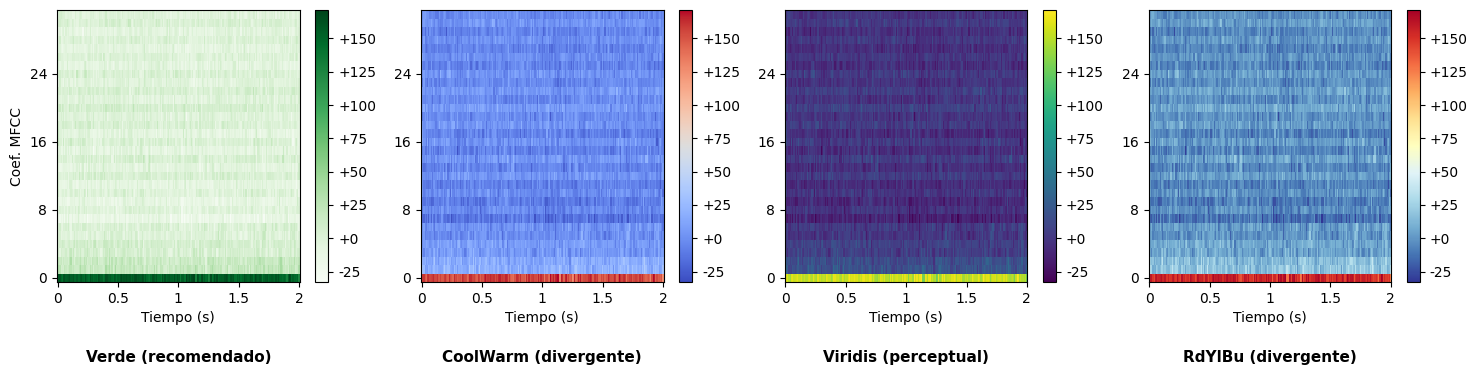

\n✓ Comparación de escalas completada
  Recomendación: 'Greens' para visualización clara y profesional


In [ ]:
# ========================================================================
# VISUALIZACIÓN COMPLETA: MFCCs, Deltas, y C0
# ========================================================================

if 'features' in locals() and len(features) > 0:
    
    # ===== PARTE 1: Visualizar features finales (sin C0) =====
    print("="*70)
    print("VISUALIZACIÓN DE FEATURES FINALES (usadas en el modelo)")
    print("="*70)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))  # Aumentado altura de 10 a 12
    
    first_segment = features[0]  # Shape: (3, 32, T)
    
    # ============ PANEL (a): MFCC (canal 0) - sin C0 ============
    im0 = librosa.display.specshow(
        first_segment[0], 
        x_axis='time', 
        hop_length=HOP_LEN,
        sr=SR,
        ax=axes[0],
        cmap='Greens'
    )
    axes[0].set_ylabel('Coeficiente MFCC', fontsize=12)
    # Ajustar ticks del eje Y para evitar amontonamiento
    axes[0].set_yticks(np.arange(0, 32, 5))  # Cada 5 coeficientes: 0, 5, 10, 15, 20, 25, 30
    axes[0].set_yticklabels(np.arange(0, 32, 5))
    # Etiqueta del eje X (tiempo)
    axes[0].set_xlabel('Tiempo (s)', fontsize=12)
    # Colorbar
    cbar0 = fig.colorbar(im0, ax=axes[0], format='%+2.0f')
    cbar0.set_label('Magnitud', fontsize=10)
    
    # ============ PANEL (b): Delta (canal 1) ============
    im1 = librosa.display.specshow(
        first_segment[1], 
        x_axis='time', 
        hop_length=HOP_LEN,
        sr=SR,
        ax=axes[1],
        cmap='Greens'
    )
    axes[1].set_ylabel('Coeficiente MFCC', fontsize=12)
    axes[1].set_yticks(np.arange(0, 32, 5))
    axes[1].set_yticklabels(np.arange(0, 32, 5))
    axes[1].set_xlabel('Tiempo (s)', fontsize=12)
    cbar1 = fig.colorbar(im1, ax=axes[1], format='%+2.0f')
    cbar1.set_label('Magnitud', fontsize=10)
    
    # ============ PANEL (c): Delta-Delta (canal 2) ============
    im2 = librosa.display.specshow(
        first_segment[2], 
        x_axis='time', 
        hop_length=HOP_LEN,
        sr=SR,
        ax=axes[2],
        cmap='Greens'
    )
    axes[2].set_ylabel('Coeficiente MFCC', fontsize=12)
    axes[2].set_yticks(np.arange(0, 32, 5))
    axes[2].set_yticklabels(np.arange(0, 32, 5))
    axes[2].set_xlabel('Tiempo (s)', fontsize=12)
    cbar2 = fig.colorbar(im2, ax=axes[2], format='%+2.0f')
    cbar2.set_label('Magnitud', fontsize=10)
    
    # ============ TÍTULOS COMO TEXTO CENTRADO DEBAJO ============
    # Agregar títulos debajo de cada panel con espacio adecuado
    fig.text(0.45, 0.67, '(a) MFCCs (32 coefs, C0 eliminado)', 
             ha='center', fontsize=14, fontweight='bold')
    fig.text(0.45, 0.34, '(b) Delta (Δ) - Primera derivada', 
             ha='center', fontsize=14, fontweight='bold')
    fig.text(0.45, 0.02, '(c) Delta-Delta (ΔΔ) - Segunda derivada', 
             ha='center', fontsize=14, fontweight='bold')
    
    # Ajustar espaciado entre subplots
    plt.subplots_adjust(hspace=0.4, bottom=0.08, top=0.96)
    
    plt.show()
    
    print(f"\\n✓ Visualización de features finales completada")
    print(f"  Shape: {first_segment.shape} → (canales, coeficientes, frames)")
    
    
    # ===== PARTE 2: Extraer y visualizar C0 (para comparación) =====
    print("\\n" + "="*70)
    print("VISUALIZACIÓN DE C0 (coeficiente eliminado)")
    print("="*70)
    print("NOTA: C0 representa la energía promedio del espectro y suele eliminarse")
    print("      porque no aporta información discriminativa para clasificación.\\n")
    
    # Re-extraer el primer segmento CON C0 para visualización
    audio_path = AUDIO_PATH
    audio_raw, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    audio_trimmed, _ = librosa.effects.trim(audio_raw, top_db=TRIM_DB)
    audio_normalized = peak_normalize(audio_trimmed)
    segments = segment_signal(audio_normalized, SR, SEG_SEC, HOP_SEC)
    
    # Extraer MFCCs CON C0 (33 coeficientes)
    mfcc_with_c0 = librosa.feature.mfcc(
        y=segments[0],
        sr=SR,
        n_mfcc=N_MFCC_RAW,  # 33 coeficientes (incluye C0)
        n_fft=N_FFT,
        hop_length=HOP_LEN,
        fmin=FMIN,
        fmax=FMAX
    )
    
    # Visualización comparativa: C0 vs resto de coeficientes
    fig2, axes2 = plt.subplots(2, 1, figsize=(14, 8))
    
    # Solo C0 (primer coeficiente)
    c0 = mfcc_with_c0[0, :]  # Shape: (T,) - Vector 1D
    
    # Crear eje de tiempo manualmente
    times = librosa.frames_to_time(np.arange(len(c0)), sr=SR, hop_length=HOP_LEN)
    
    # Graficar C0 como línea temporal (no como heatmap)
    axes2[0].plot(times, c0, color='darkorange', linewidth=2)
    axes2[0].fill_between(times, c0, alpha=0.3, color='orange')
    axes2[0].set_ylabel('Valor de C0', fontsize=12)
    axes2[0].set_xlabel('Tiempo (s)', fontsize=12)
    axes2[0].grid(True, alpha=0.3)
    axes2[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # MFCCs sin C0 (coeficientes 1-32)
    mfcc_without_c0 = mfcc_with_c0[1:, :]  # Shape: (32, T)
    im_mfcc = librosa.display.specshow(
        mfcc_without_c0,
        x_axis='time',
        hop_length=HOP_LEN,
        sr=SR,
        ax=axes2[1],
        cmap='Greens'
    )
    axes2[1].set_ylabel('Coeficiente MFCC', fontsize=12)
    axes2[1].set_xlabel('Tiempo (s)', fontsize=12)
    axes2[1].set_yticks(np.arange(0, 32, 5))
    axes2[1].set_yticklabels(np.arange(0, 32, 5))
    cbar_mfcc = fig2.colorbar(im_mfcc, ax=axes2[1], format='%+2.0f')
    cbar_mfcc.set_label('Magnitud', fontsize=10)
    
    # Títulos centrados debajo
    fig2.text(0.5, 0.51, 'C0 (Coeficiente 0) - ELIMINADO en producción', 
              ha='center', fontsize=14, fontweight='bold')
    fig2.text(0.5, 0.03, 'MFCCs (Coeficientes 1-32) - USADOS en producción', 
              ha='center', fontsize=14, fontweight='bold')
    
    plt.subplots_adjust(hspace=0.35, bottom=0.12, top=0.96)
    plt.show()
    
    print(f"\\n✓ Visualización de C0 completada")
    print(f"  Shape con C0:    {mfcc_with_c0.shape} → (33, frames)")
    print(f"  Shape sin C0:    {mfcc_without_c0.shape} → (32, frames)")
    print(f"  C0 promedio:     {np.mean(c0):.2f}")
    print(f"  C0 rango:        [{np.min(c0):.2f}, {np.max(c0):.2f}]")
    print(f"  C0 std:          {np.std(c0):.2f}")
    
    
    # ===== PARTE 3: Visualización EXTRA - Todos los coeficientes juntos =====
    print("\\n" + "="*70)
    print("VISUALIZACIÓN COMPLETA: C0 + MFCCs 1-32")
    print("="*70)
    
    fig3, ax3 = plt.subplots(figsize=(14, 6))
    
    # Mostrar TODOS los coeficientes (0-32)
    im3 = librosa.display.specshow(
        mfcc_with_c0,
        x_axis='time',
        hop_length=HOP_LEN,
        sr=SR,
        ax=ax3,
        cmap='RdYlGn'  # Escala divergente para ver C0 vs otros
    )
    ax3.set_ylabel('Índice de Coeficiente', fontsize=12)
    ax3.set_xlabel('Tiempo (s)', fontsize=12)
    ax3.set_yticks(np.arange(0, 33, 5))
    ax3.set_yticklabels(np.arange(0, 33, 5))
    
    # Marcar línea de separación entre C0 y el resto
    ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='C0 (eliminado)')
    ax3.legend(loc='upper right', fontsize=10)
    
    cbar3 = fig3.colorbar(im3, ax=ax3, format='%+2.0f')
    cbar3.set_label('Magnitud', fontsize=10)
    
    # Título centrado debajo
    fig3.text(0.45, 0.01, 'Todos los Coeficientes MFCC (C0 + 1-32)', 
              ha='center', fontsize=14, fontweight='bold')
    
    plt.subplots_adjust(bottom=0.12)
    plt.show()
    
    print(f"\\n✓ Visualización completa generada")
    print("  Observa cómo C0 (fila 0) tiene un comportamiento diferente al resto")
    
    
    # ===== PARTE 4: Comparación de escalas de colores =====
    print("\\n" + "="*70)
    print("COMPARACIÓN DE ESCALAS DE COLORES")
    print("="*70)
    
    fig4, axes4 = plt.subplots(1, 4, figsize=(18, 4))
    
    cmaps = ['Greens', 'coolwarm', 'viridis', 'RdYlBu_r']
    titles = ['Verde (recomendado)', 'CoolWarm (divergente)', 'Viridis (perceptual)', 'RdYlBu (divergente)']
    
    for i, (cmap, title) in enumerate(zip(cmaps, titles)):
        im = librosa.display.specshow(
            first_segment[0],
            x_axis='time',
            hop_length=HOP_LEN,
            sr=SR,
            ax=axes4[i],
            cmap=cmap
        )
        axes4[i].set_ylabel('Coef. MFCC' if i == 0 else '', fontsize=10)
        axes4[i].set_xlabel('Tiempo (s)', fontsize=10)
        axes4[i].set_yticks(np.arange(0, 32, 8))
        axes4[i].set_yticklabels(np.arange(0, 32, 8))
        cbar = fig4.colorbar(im, ax=axes4[i], format='%+2.0f')
        
        # Título centrado debajo de cada panel
        axes4[i].text(0.5, -0.25, title, ha='center', va='top', 
                     fontsize=11, fontweight='bold', 
                     transform=axes4[i].transAxes)
    
    plt.subplots_adjust(bottom=0.2, hspace=0.4)
    plt.show()
    
    print("\\n✓ Comparación de escalas completada")
    print("  Recomendación: 'Greens' para visualización clara y profesional")
    
else:
    print("⚠️ No hay features para visualizar. Ejecuta la Celda 5 primero.")

✓ Usando audio real: 960000 samples (60.0s)


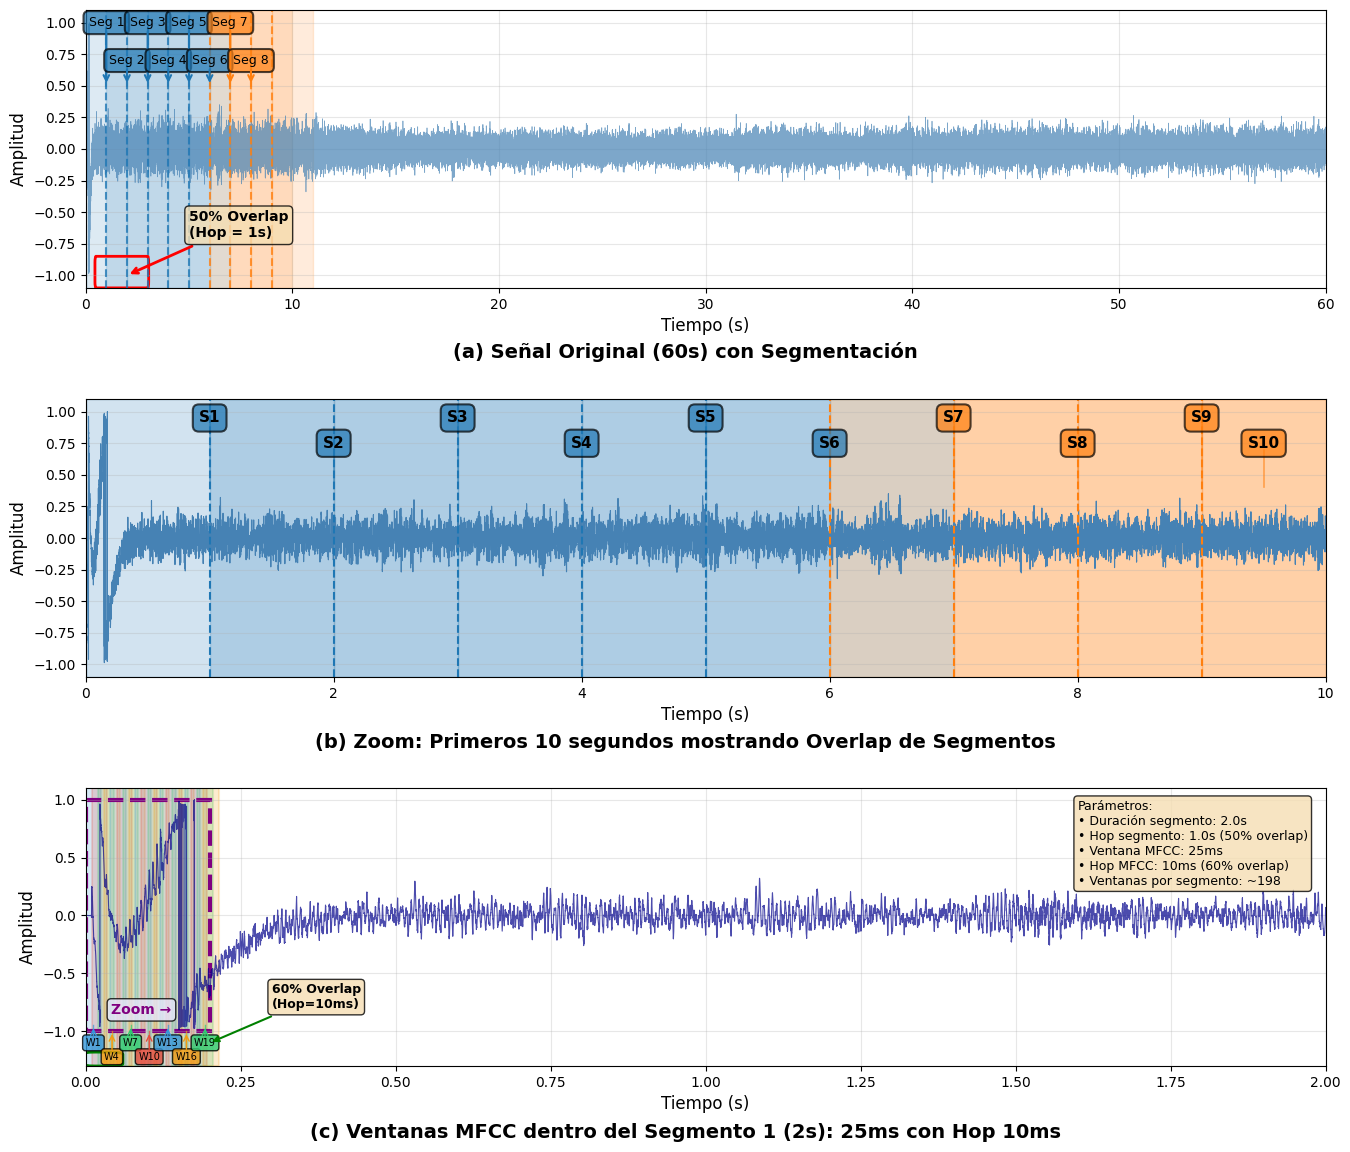

\n======================================================================
RESUMEN DE SEGMENTACIÓN Y VENTANADO
Audio total:              60s (960000 samples)
Segmentos de:             2.0s
Hop entre segmentos:      1.0s (overlap 50%)
Número de segmentos:      ~59
\nVentanas MFCC por segmento:
  Duración ventana:       25.0ms (400 samples)
  Hop ventana:            10.0ms (160 samples)
  Overlap ventana:        60.0%
  Ventanas por segmento:  ~198
\nShape final por segmento: (3, 32, ~198)


In [164]:
# ========================================================================
# VISUALIZACIÓN: Segmentación y Ventanado del Pipeline
# ========================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

# Generar señal sintética similar a la de 60s (o cargar tu audio real)
# Opción 1: Usar tu audio real de 60s
try:
    audio_60s, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
    audio_60s_trimmed, _ = librosa.effects.trim(audio_60s, top_db=TRIM_DB)
    audio_60s_norm = peak_normalize(audio_60s_trimmed)
    
    # Ajustar duración a exactamente 60s si es necesario
    target_len = 60 * SR
    if len(audio_60s_norm) < target_len:
        audio_60s_norm = np.pad(audio_60s_norm, (0, target_len - len(audio_60s_norm)), mode='reflect')
    else:
        audio_60s_norm = audio_60s_norm[:target_len]
    
    duration = 60
    print(f"✓ Usando audio real: {len(audio_60s_norm)} samples ({len(audio_60s_norm)/SR:.1f}s)")
    
except:
    # Opción 2: Señal sintética (si no tienes el audio)
    print("⚠️ Generando señal sintética de ejemplo")
    duration = 60  # segundos
    t = np.linspace(0, duration, duration * SR)
    # Señal con componentes de frecuencia variable
    audio_60s_norm = (
        0.5 * np.sin(2 * np.pi * 200 * t) +  # 200 Hz
        0.3 * np.sin(2 * np.pi * 400 * t) +  # 400 Hz
        0.2 * np.sin(2 * np.pi * 600 * t) +  # 600 Hz
        0.1 * np.random.randn(len(t))        # Ruido
    )
    audio_60s_norm = peak_normalize(audio_60s_norm)

# Crear eje de tiempo
time_axis = np.linspace(0, duration, len(audio_60s_norm))

# =====================================================================
# FIGURA 1: Segmentación a nivel de archivo (2s con hop 1s)
# =====================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Marcar segmentos de 2s con hop de 1s
seg_starts = np.arange(0, duration - SEG_SEC + HOP_SEC, HOP_SEC)
colors = plt.cm.tab10(np.linspace(0, 1, len(seg_starts)))

# ============ PANEL (a): Señal original con marcas de segmentación ============
axes[0].plot(time_axis, audio_60s_norm, color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Amplitud', fontsize=12)
axes[0].set_xlim(0, duration)
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

# Alturas alternadas para etiquetas
label_heights = [1.0, 0.7]  # Dos alturas diferentes
label_y_offset = 0.05  # Offset para las líneas conectoras

for i, start in enumerate(seg_starts[:10]):  # Mostrar primeros 10 segmentos
    end = start + SEG_SEC
    axes[0].axvspan(start, end, alpha=0.15, color=colors[i])
    axes[0].axvline(start, color=colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    
    if i < 8:  # Etiquetar primeros 8 (más legible)
        # Alternar altura según índice par/impar
        label_y = label_heights[i % 2]
        label_x = start + SEG_SEC / 2  # Centro del segmento
        
        # Etiqueta con fondo
        axes[0].text(label_x, label_y, f'Seg {i+1}', fontsize=9, 
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.4', 
                              facecolor=colors[i], 
                              edgecolor='black',
                              alpha=0.7,
                              linewidth=1.5))
        
        # Línea conectora desde etiqueta al segmento
        axes[0].plot([label_x, label_x], [label_y - label_y_offset, 0.5], 
                    color=colors[i], linestyle='-', linewidth=1.5, alpha=0.6)
        
        # Flecha pequeña apuntando al segmento
        axes[0].annotate('', xy=(label_x, 0.5), xytext=(label_x, label_y - label_y_offset),
                        arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.5))

# Mostrar zoom de overlap
axes[0].add_patch(FancyBboxPatch((0.5, -1.05), 2.5, 0.15, 
                                  boxstyle="round,pad=0.05", 
                                  edgecolor='red', facecolor='none', linewidth=2))
axes[0].annotate('50% Overlap\n(Hop = 1s)', xy=(2, -1.0), xytext=(5, -0.7),
                fontsize=10, color='black', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============ PANEL (b): Zoom de primeros 10 segundos ============
zoom_duration = 10
zoom_samples = int(zoom_duration * SR)
axes[1].plot(time_axis[:zoom_samples], audio_60s_norm[:zoom_samples], 
             color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Amplitud', fontsize=12)
axes[1].set_xlim(0, zoom_duration)
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)

# Mostrar segmentos con overlap
label_heights_zoom = [0.95, 0.75]

for i, start in enumerate(seg_starts[:10]):
    if start >= zoom_duration:
        break
    end = min(start + SEG_SEC, zoom_duration)
    axes[1].axvspan(start, end, alpha=0.2, color=colors[i])
    axes[1].axvline(start, color=colors[i], linestyle='--', linewidth=1.5)
    
    # Etiqueta con altura alternada
    label_y = label_heights_zoom[i % 2]
    label_x = start + (end - start) / 2
    
    axes[1].text(label_x, label_y, f'S{i+1}', fontsize=11, fontweight='bold',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.4', 
                          facecolor=colors[i], 
                          edgecolor='black',
                          alpha=0.7,
                          linewidth=1.5))
    
    # Línea conectora
    axes[1].plot([label_x, label_x], [label_y - 0.05, 0.4], 
                color=colors[i], linestyle='-', linewidth=1.2, alpha=0.6)

# ============ PANEL (c): Ventanas MFCC dentro de un segmento de 2s ============
first_segment = audio_60s_norm[:int(SEG_SEC * SR)]
seg_time_axis = np.linspace(0, SEG_SEC, len(first_segment))

axes[2].plot(seg_time_axis, first_segment, color='darkblue', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Amplitud', fontsize=12)
axes[2].set_xlim(0, SEG_SEC)
axes[2].set_ylim(-1.3, 1.1)
axes[2].grid(True, alpha=0.3)

# Mostrar ventanas MFCC (25ms con hop 10ms)
win_duration_s = N_FFT / SR  # 400 samples / 16000 = 0.025s
hop_duration_s = HOP_LEN / SR  # 160 samples / 16000 = 0.010s
num_windows = int((SEG_SEC - win_duration_s) / hop_duration_s) + 1

# Paleta de 4 colores contrastantes que se repiten cíclicamente
distinctive_colors = ['#3498db',  # Azul
                     '#e74c3c',  # Rojo
                     '#2ecc71',  # Verde
                     '#f39c12']  # Naranja

# Mostrar primeras 20 ventanas con colores alternados
num_windows_to_show = min(20, num_windows)

for i in range(num_windows_to_show):
    win_start = i * hop_duration_s
    win_end = win_start + win_duration_s
    color = distinctive_colors[i % 4]  # Ciclar entre 4 colores
    axes[2].axvspan(win_start, win_end, alpha=0.2, color=color, 
                   edgecolor=color, linewidth=1.5)

# Etiquetar ventanas selectas con alturas alternadas
label_windows = [0, 3, 6, 9, 12, 15, 18]  # Ventanas clave
label_y_positions = [-1.10, -1.22]

for idx, i in enumerate(label_windows):
    if i >= num_windows_to_show:
        break
    
    win_start = i * hop_duration_s
    win_center = win_start + win_duration_s / 2
    label_y = label_y_positions[idx % 2]
    color = distinctive_colors[i % 4]
    
    axes[2].text(win_center, label_y, f'W{i+1}', fontsize=7, 
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.3', 
                          facecolor=color, 
                          edgecolor='black',
                          alpha=0.8,
                          linewidth=1))
    
    connector_top = -0.95 if idx % 2 == 0 else -1.00
    axes[2].plot([win_center, win_center], [label_y + 0.04, connector_top], 
                color=color, linestyle='-', linewidth=1, alpha=0.7)
    
    axes[2].annotate('', xy=(win_center, connector_top), 
                    xytext=(win_center, label_y + 0.04),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

# Cuadro de zoom para indicar área ampliada
zoom_region = patches.Rectangle((0.0, -1.0), 0.2, 2.0, 
                                linewidth=3, edgecolor='purple', 
                                facecolor='none', linestyle='--')
axes[2].add_patch(zoom_region)
axes[2].text(0.09, -0.85, 'Zoom →', fontsize=10, ha='center', 
            color='purple', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

# Indicador de solapamiento (CORREGIDO: 60% no 96%)
# Cálculo: overlap = (win_duration - hop) / win_duration = (400-160)/400 = 60%
axes[2].add_patch(FancyBboxPatch((0.015, -1.28), 0.025, 0.08, 
                                  boxstyle="round,pad=0.02", 
                                  edgecolor='green', facecolor='none', linewidth=2))
axes[2].annotate('60% Overlap\n(Hop=10ms)', xy=(0.2, -1.1), xytext=(0.30, -0.8),
                fontsize=9, color='black', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Parámetros
textstr = '\n'.join([
    'Parámetros:',
    f'• Duración segmento: {SEG_SEC}s',
    f'• Hop segmento: {HOP_SEC}s (50% overlap)',
    f'• Ventana MFCC: {win_duration_s*1000:.0f}ms',
    f'• Hop MFCC: {hop_duration_s*1000:.0f}ms (60% overlap)',
    f'• Ventanas por segmento: ~{num_windows}'
])
axes[2].text(1.6, 1, textstr, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============ TÍTULOS CENTRADOS DEBAJO DE CADA PANEL ============
fig.text(0.5, 0.67, '(a) Señal Original (60s) con Segmentación', 
         ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.345, '(b) Zoom: Primeros 10 segundos mostrando Overlap de Segmentos', 
         ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.02, '(c) Ventanas MFCC dentro del Segmento 1 (2s): 25ms con Hop 10ms', 
         ha='center', fontsize=14, fontweight='bold')

# Etiquetas de tiempo en eje X
axes[0].set_xlabel('Tiempo (s)', fontsize=12)
axes[1].set_xlabel('Tiempo (s)', fontsize=12)
axes[2].set_xlabel('Tiempo (s)', fontsize=12)

# Ajustar espaciado
plt.subplots_adjust(hspace=0.4, bottom=0.08, top=0.96)
plt.show()

# ============ RESUMEN IMPRESO ============
print("\\n" + "="*70)
print("RESUMEN DE SEGMENTACIÓN Y VENTANADO")
print("="*70)
print(f"Audio total:              {duration}s ({len(audio_60s_norm)} samples)")
print(f"Segmentos de:             {SEG_SEC}s")
print(f"Hop entre segmentos:      {HOP_SEC}s (overlap {(1 - HOP_SEC/SEG_SEC)*100:.0f}%)")
print(f"Número de segmentos:      ~{len(seg_starts)}")
print(f"\\nVentanas MFCC por segmento:")
print(f"  Duración ventana:       {win_duration_s*1000:.1f}ms ({N_FFT} samples)")
print(f"  Hop ventana:            {hop_duration_s*1000:.1f}ms ({HOP_LEN} samples)")
print(f"  Overlap ventana:        {(1 - HOP_LEN/N_FFT)*100:.1f}%")  # Esto da 60%
print(f"  Ventanas por segmento:  ~{num_windows}")
print(f"\\nShape final por segmento: (3, 32, ~{num_windows})")
print("="*70)


GENERANDO ZOOM DETALLADO DE VENTANAS MFCC...


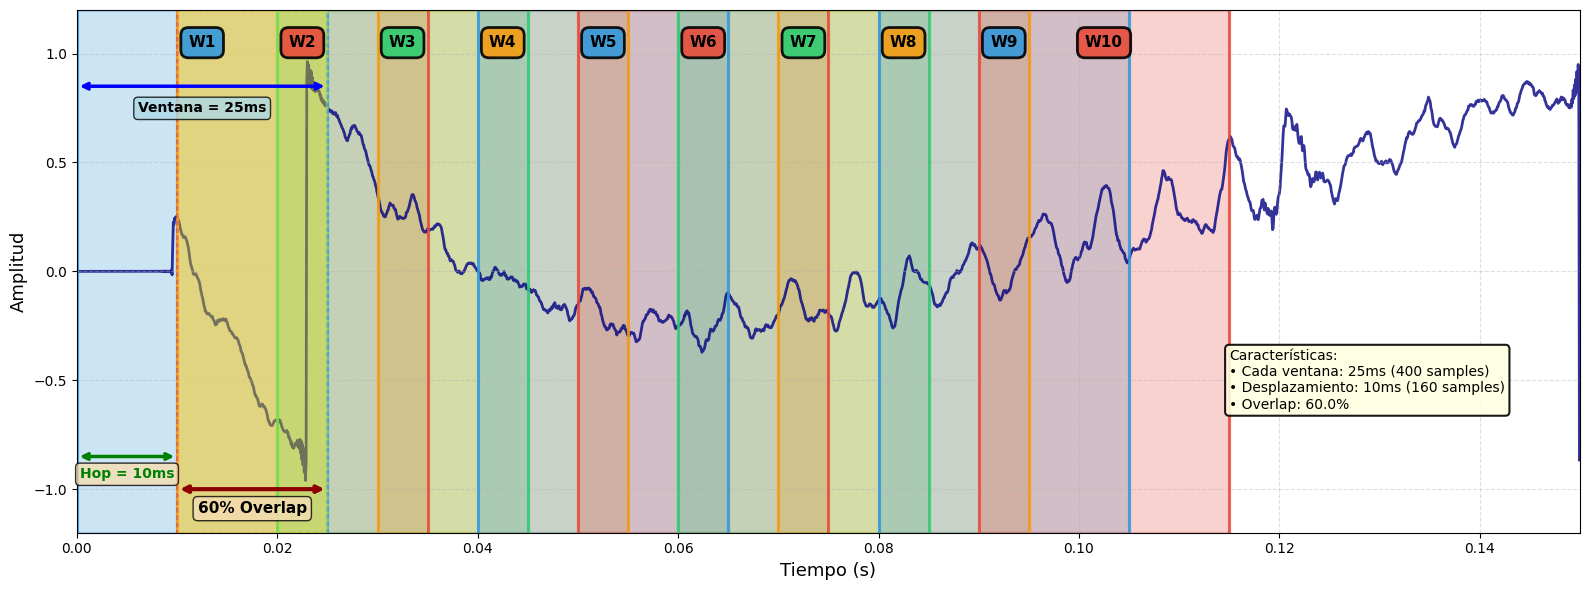

✓ Zoom detallado generado exitosamente
  Mostrando primeras 10 ventanas
  Duración visualizada: 150ms


In [167]:
# =====================================================================
# FIGURA ADICIONAL: ZOOM EXTREMO - Primeras 10 Ventanas
# =====================================================================

print("\n" + "="*70)
print("GENERANDO ZOOM DETALLADO DE VENTANAS MFCC...")
print("="*70)

fig_zoom, ax_zoom = plt.subplots(figsize=(16, 6))

# Zoom a los primeros 0.15 segundos (suficiente para ver ~15 ventanas)
zoom_duration = 0.15
zoom_samples = int(zoom_duration * SR)
zoom_segment = first_segment[:zoom_samples]
zoom_time = seg_time_axis[:zoom_samples]

# Graficar señal
ax_zoom.plot(zoom_time, zoom_segment, color='navy', linewidth=2, alpha=0.8, zorder=1)
ax_zoom.set_xlabel('Tiempo (s)', fontsize=13)
ax_zoom.set_ylabel('Amplitud', fontsize=13)
ax_zoom.set_xlim(0, zoom_duration)
ax_zoom.set_ylim(-1.2, 1.2)
ax_zoom.grid(True, alpha=0.4, linestyle='--')

# Paleta de 4 colores distintivos
distinctive_colors = ['#3498db',  # Azul brillante
                     '#e74c3c',  # Rojo
                     '#2ecc71',  # Verde brillante
                     '#f39c12']  # Naranja

# Mostrar primeras 10 ventanas
num_zoom_windows = 10

for i in range(num_zoom_windows):
    win_start = i * hop_duration_s
    win_end = win_start + win_duration_s
    
    if win_end > zoom_duration:
        break
    
    color = distinctive_colors[i % 4]
    
    # Ventana coloreada
    ax_zoom.axvspan(win_start, win_end, alpha=0.25, color=color, 
                   edgecolor=color, linewidth=2.5, zorder=0)
    
    # Líneas verticales en los bordes
    ax_zoom.axvline(win_start, color=color, linestyle='-', linewidth=2, alpha=0.9)
    ax_zoom.axvline(win_end, color=color, linestyle='-', linewidth=2, alpha=0.9)
    
    # Etiqueta centrada en cada ventana
    win_center = (win_start + win_end) / 2
    ax_zoom.text(win_center, 1.05, f'W{i+1}', fontsize=11, fontweight='bold',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.5', 
                          facecolor=color, 
                          edgecolor='black',
                          alpha=0.9,
                          linewidth=2))

# Agregar anotaciones de overlap
# Mostrar overlap entre W1 y W2
if num_zoom_windows >= 2:
    overlap_start = hop_duration_s
    overlap_end = win_duration_s
    
    # Zona de overlap
    ax_zoom.axvspan(overlap_start, overlap_end, 
                   alpha=0.35, color='yellow', zorder=2,
                   edgecolor='darkgoldenrod', linewidth=2, linestyle=':')
    
    # Anotación del overlap
    overlap_center = (overlap_start + overlap_end) / 2
    ax_zoom.annotate('', xy=(overlap_start, -1.0), xytext=(overlap_end, -1.0),
                    arrowprops=dict(arrowstyle='<->', color='darkred', lw=3))
    ax_zoom.text(overlap_center, -1.11, '60% Overlap', fontsize=11, ha='center',
                fontweight='bold', color='black',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Indicadores de duración de ventana
if num_zoom_windows >= 1:
    ax_zoom.annotate('', xy=(0, 0.85), xytext=(win_duration_s, 0.85),
                    arrowprops=dict(arrowstyle='<->', color='blue', lw=2.5))
    ax_zoom.text(win_duration_s/2, 0.73, f'Ventana = {win_duration_s*1000:.0f}ms', 
                fontsize=10, ha='center', fontweight='bold', color='black',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Indicador de hop
if num_zoom_windows >= 2:
    ax_zoom.annotate('', xy=(0, -0.85), xytext=(hop_duration_s, -0.85),
                    arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))
    ax_zoom.text(hop_duration_s/2, -0.95, f'Hop = {hop_duration_s*1000:.0f}ms', 
                fontsize=10, ha='center', fontweight='bold', color='green',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Información adicional
info_text = '\n'.join([
    'Características:',
    f'• Cada ventana: {win_duration_s*1000:.0f}ms ({N_FFT} samples)',
    f'• Desplazamiento: {hop_duration_s*1000:.0f}ms ({HOP_LEN} samples)',
    f'• Overlap: {(1 - HOP_LEN/N_FFT)*100:.1f}%'
])
ax_zoom.text(0.115, -0.5, info_text, fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='lightyellow', 
                     edgecolor='black', alpha=0.9, linewidth=1.5),
            verticalalignment='center')

plt.tight_layout()
plt.show()

print("✓ Zoom detallado generado exitosamente")
print(f"  Mostrando primeras {num_zoom_windows} ventanas")
print(f"  Duración visualizada: {zoom_duration*1000:.0f}ms")

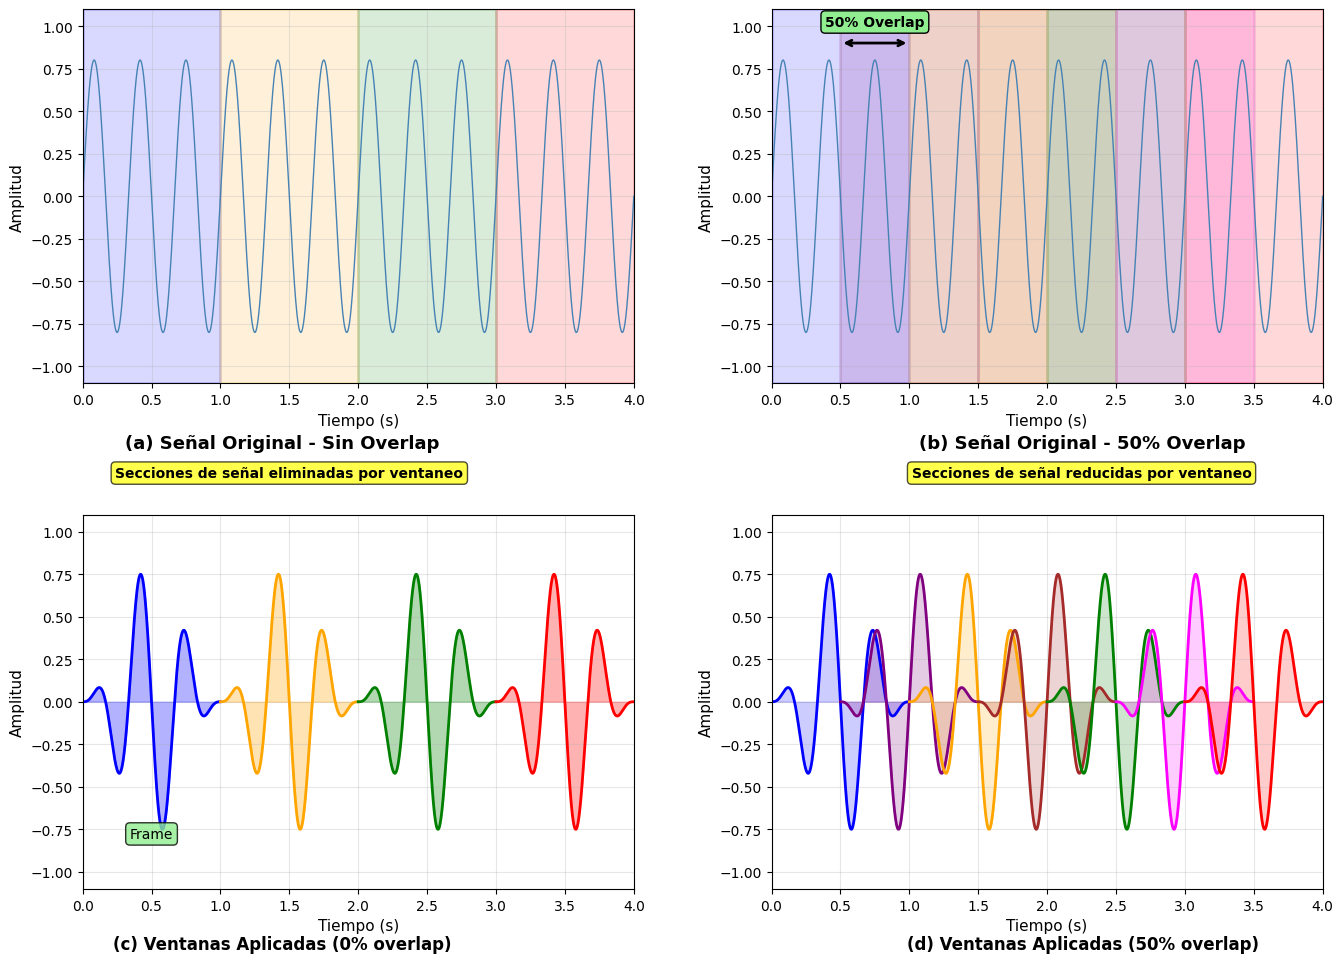


✓ Gráficos de comparación generados exitosamente


In [166]:
# ========================================================================
# FIGURA 2: Comparación de Overlap (estilo imagen de referencia)
# ========================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Generar señal corta de ejemplo (4 segundos)
duration_short = 4
t_short = np.linspace(0, duration_short, duration_short * SR)
signal_short = 0.8 * np.sin(2 * np.pi * 3 * t_short)  # 3 Hz para visualización clara

# ============ COLUMNA 1: 0% Overlap (Hop = Duración de ventana) ============
axes[0, 0].plot(t_short, signal_short, color='steelblue', linewidth=1)
axes[0, 0].set_ylabel('Amplitud', fontsize=11)
axes[0, 0].set_xlabel('Tiempo (s)', fontsize=11)
axes[0, 0].set_xlim(0, duration_short)
axes[0, 0].set_ylim(-1.1, 1.1)
axes[0, 0].grid(True, alpha=0.3)

# Ventanas sin overlap (hop = duración)
seg_dur_no_overlap = 1.0  # 1 segundo
colors_no_overlap = ['blue', 'orange', 'green', 'red']
for i in range(4):
    start = i * seg_dur_no_overlap
    end = start + seg_dur_no_overlap
    axes[0, 0].axvspan(start, end, alpha=0.15, color=colors_no_overlap[i], 
                       edgecolor=colors_no_overlap[i], linewidth=2)

axes[0, 0].text(1.5, -1.65, 'Secciones de señal eliminadas por ventaneo', 
                fontsize=10, ha='center', color='black', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Ventanas Hanning aplicadas (panel inferior izquierdo)
axes[1, 0].set_ylabel('Amplitud', fontsize=11)
axes[1, 0].set_xlabel('Tiempo (s)', fontsize=11)
axes[1, 0].set_xlim(0, duration_short)
axes[1, 0].set_ylim(-1.1, 1.1)
axes[1, 0].grid(True, alpha=0.3)

for i in range(4):
    start = i * seg_dur_no_overlap
    end = start + seg_dur_no_overlap
    start_idx = int(start * SR)
    end_idx = int(end * SR)
    
    # Aplicar ventana Hanning
    segment = signal_short[start_idx:end_idx]
    window = np.hanning(len(segment))
    windowed_segment = segment * window
    
    t_segment = t_short[start_idx:end_idx]
    axes[1, 0].plot(t_segment, windowed_segment, color=colors_no_overlap[i], linewidth=2)
    axes[1, 0].fill_between(t_segment, 0, windowed_segment, alpha=0.3, color=colors_no_overlap[i])

axes[1, 0].text(0.5, -0.8, 'Frame', fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# ============ COLUMNA 2: 50% Overlap (Hop = 50% duración) ============
axes[0, 1].plot(t_short, signal_short, color='steelblue', linewidth=1)
axes[0, 1].set_ylabel('Amplitud', fontsize=11)
axes[0, 1].set_xlabel('Tiempo (s)', fontsize=11)
axes[0, 1].set_xlim(0, duration_short)
axes[0, 1].set_ylim(-1.1, 1.1)
axes[0, 1].grid(True, alpha=0.3)

# Ventanas con 50% overlap
seg_dur_overlap = 1.0
hop_overlap = 0.5  # 50% overlap
colors_overlap = ['blue', 'purple', 'orange', 'brown', 'green', 'magenta', 'red']
num_segs_overlap = int((duration_short - seg_dur_overlap) / hop_overlap) + 1

for i in range(num_segs_overlap):
    start = i * hop_overlap
    end = start + seg_dur_overlap
    if end > duration_short:
        break
    axes[0, 1].axvspan(start, end, alpha=0.15, color=colors_overlap[i], 
                       edgecolor=colors_overlap[i], linewidth=2)

axes[0, 1].text(2.25, -1.65, 'Secciones de señal reducidas por ventaneo', 
                fontsize=10, ha='center', color='black', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Indicador de overlap
axes[0, 1].annotate('', xy=(1.0, 0.9), xytext=(0.5, 0.9),
                    arrowprops=dict(arrowstyle='<->', color='black', lw=2))
axes[0, 1].text(0.75, 1.0, '50% Overlap', fontsize=10, ha='center', color='black',
                fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightgreen'))

# Ventanas aplicadas con overlap (panel inferior derecho)
axes[1, 1].set_ylabel('Amplitud', fontsize=11)
axes[1, 1].set_xlabel('Tiempo (s)', fontsize=11)
axes[1, 1].set_xlim(0, duration_short)
axes[1, 1].set_ylim(-1.1, 1.1)
axes[1, 1].grid(True, alpha=0.3)

for i in range(num_segs_overlap):
    start = i * hop_overlap
    end = start + seg_dur_overlap
    if end > duration_short:
        break
    start_idx = int(start * SR)
    end_idx = int(end * SR)
    
    segment = signal_short[start_idx:end_idx]
    window = np.hanning(len(segment))
    windowed_segment = segment * window
    
    t_segment = t_short[start_idx:end_idx]
    axes[1, 1].plot(t_segment, windowed_segment, color=colors_overlap[i], linewidth=2)
    axes[1, 1].fill_between(t_segment, 0, windowed_segment, alpha=0.2, color=colors_overlap[i])

# ============ TÍTULOS CENTRADOS DEBAJO ============
fig.text(0.25, 0.521, '(a) Señal Original - Sin Overlap', 
         ha='center', fontsize=13, fontweight='bold')
fig.text(0.75, 0.521, '(b) Señal Original - 50% Overlap', 
         ha='center', fontsize=13, fontweight='bold')
fig.text(0.25, 0.02, '(c) Ventanas Aplicadas (0% overlap)', 
         ha='center', fontsize=12, fontweight='bold')
fig.text(0.75, 0.02, '(d) Ventanas Aplicadas (50% overlap)', 
         ha='center', fontsize=12, fontweight='bold')

plt.subplots_adjust(hspace=0.35, wspace=0.25, bottom=0.08, top=0.96)
plt.show()

print("\n✓ Gráficos de comparación generados exitosamente")